# Imports

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import correlate
from scipy.interpolate import interp1d
from hapi import *
from pylab import plot
import pickle
from scipy.stats import chi2
from scipy.stats import norm
import matplotlib.ticker as ticker
from pathlib import Path
import gc
from concurrent.futures import ProcessPoolExecutor, as_completed


# from bin_spec import bin_spectrum
import seaborn as sns

%matplotlib widget


In [6]:
os.chdir('/Users/zaniaccollins/Research/SGL/sgl_science_case')

In [13]:
os.getcwd()

'/Users/zaniaccollins/Research/SGL/sgl_science_case'

In [16]:
data_path = '/Users/zaniaccollins/Research/SGL/sgl_science_case/data/xsc_spectra'
# spectra_dict_path = f'{data_path}spectra_dict_cache_dwn1e-4_earth/'

# Helper functions

In [8]:
def get_molecule_id(molecule_name):
    """Return (M, common_local_I) for a molecule by name"""
    for (M, I), data in hapi.ISO.items():
        if data[4].upper() == molecule_name.upper():   # data[4] is the molecule name like 'N2O'
            return M, I   # returns first (main) isotopologue
    raise ValueError(f"Molecule {molecule_name} not found in hapi.ISO")

def cross_correlate_spectra(template_spectra, test_spectra, lags=None, return_full=True):
    """
    Perform zero-mean normalized cross-correlation between two spectra.
    Returns a dictionary with all relevant results.
    """
    # Zero-mean normalization
    template_norm = (template_spectra - np.mean(template_spectra)) / np.std(template_spectra)
    test_norm     = (test_spectra     - np.mean(test_spectra))     / np.std(test_spectra)
    
    # Cross-correlation
    ccf = correlate(template_norm, test_norm, mode='full')
    ccf /= np.sqrt(np.sum(template_norm**2) * np.sum(test_norm**2))
    
    # Lags
    if lags is None:
        lags = np.arange(-len(template_norm) + 1, len(template_norm))
    
    # Basic statistics
    max_corr = np.max(ccf)
    peak_idx = np.argmax(ccf)
    
    # Noise estimation from wings (excluding central peak)
    window_size = int(0.15 * len(ccf))
    noise_mask = np.ones(len(ccf), dtype=bool)
    noise_mask[max(0, peak_idx - window_size): min(len(ccf), peak_idx + window_size)] = False
    noise_values = ccf[noise_mask]
    noise_std = np.std(noise_values) if len(noise_values) > 20 else np.std(ccf)
    
    # SNR array
    cc_snr = ccf / noise_std if noise_std > 0 else np.zeros_like(ccf)
    
    results = {
        'ccf': ccf,
        'lags': lags,
        'max_correlation': max_corr,
        'peak_lag': lags[peak_idx],
        'noise_std': noise_std,
        'template_norm': template_norm,
        'test_norm': test_norm,
    }
    
    if return_full:
        results['ccf_clean'] = np.clip(np.nan_to_num(ccf, nan=0.0), 0, None)
    
    return results

def compute_log_likelihood(template, test):
    """
    Log-likelihood computation according to ana's paper
    """
    # Zero mean subtraction (used in paper)
    f = template - np.mean(template)
    g = test - np.mean(test)

    # print('Template mean: ', np.mean(template))

    N = len(f)

    # print('Num bins: ', N)
    
    # amplitude scaling a (force to one)
    a =  np.dot(f, g) / np.dot(g, g) if np.dot(g, g) > 0 else 1.0

    # Variances and cross-covariance
    s_f2 = 1/N * np.sum(f**2)
    s_g2 = 1/N * np.sum(g**2) #np.mean((a * g)**2)
    R = 1/N * np.sum(f * g) #np.mean(f * a * g)
    
    # print(f'Variances - Template: {s_f2}, Data: {s_g2}, CC: {R}')

    # residuals = f - a * g
    
    # noise_std = np.std(residuals)
    

    # Log-likelihood from equation (9)
    argument = s_f2 - 2 * R + s_g2
    if argument <= 0:
        argument = 1e-10  # prevent log of negative/zero
        print('argument less than = 0')
    
    logL = - (N / 2.0) * np.log(argument)
    
    # print('LogL: ', logL)

    return logL, a

def load_scenario(scenario_key, out_dir=None):
    if out_dir is None:
        out_dir = os.path.expanduser("~/orcd/pool/sgl_science_case/spectra_dict_cache")
    path = os.path.join(out_dir, f"{scenario_key}.pkl")
    with open(path, "rb") as f:
        return pickle.load(f)

def planck_wn(wn_cm, T):
    """Planck function in wavenumber units [wn in cm^-1, T in K].
    Returns B_wn in erg/s/cm^2/sr/cm^-1 (cgs). Scale is arbitrary for template matching.
    """
    # B_ν = 2 h c^2 ν^3 / (exp(hcν/kT) - 1)
    # ν in cm^-1; use hc/k = 1.4388 cm K
    wn = np.asarray(wn_cm, dtype=np.float64)
    c1 = 1.191042972e-5   # 2hc^2 in appropriate cgs scaling for wn
    c2 = 1.4387769          # hc/k [cm K]
    x = c2 * wn / T
    # stable for large x
    return c1 * wn**3 / np.expm1(x)

def planck_wavelength(wl_um, T):
    """
    Planck function on a wavelength grid.
    wl_um : array in micrometers
    T     : temperature in K
    Returns B_lambda (relative units; fine for overplotting / normalization).
    """
    wl_um = np.asarray(wl_um, dtype=np.float64)
    # convert µm → cm^-1
    wn_cm = 1e4 / wl_um
    B_wn = planck_wn(wn_cm, T)

    # Optional: convert B_ν → B_λ so the continuum shape matches
    # wavelength-plotted spectra. B_λ dλ = B_ν dν, |dν/dλ| = 1e4 / λ^2
    # with λ in µm, ν in cm^-1.
    B_wl = B_wn * (1e4 / wl_um**2)
    return B_wl

kB = 1.380649e-23  # Boltzmann constant, J/K

def cross_correlate_two_templates(template_A, template_B, test_scenario, in_dir = "/home/zaniacco/orcd/pool/sgl_science_case/"):
    """
    Cross-correlate two specific clean templates against the noisy versions
    of a single test scenario.
    """  

    print(f"Loading scenarios...")
    data_A = load_scenario(template_A, in_dir)
    data_B = load_scenario(template_B, in_dir)
    data_test = load_scenario(test_scenario, in_dir)

    # Only use resolutions that exist in all three
    common_resolutions = sorted(
        set(data_A.keys()) & set(data_B.keys()) & set(data_test.keys())
    )
    print('Common resolutions: ', common_resolutions)

    records = []

    for r in common_resolutions:
        # Check that everything we need exists
        template_A_spec = data_A[r]['radiance_clean'][1:-1] # avoid nans; artifact of binning
        template_B_spec = data_B[r]['radiance_clean'][1:-1]

        # Loop over noisy versions of the test scenario at this resolution
        for key in data_test[r]:
            if not key.startswith('radiance_snr'):
                continue

            noisy_spec = data_test[r][key][1:-1] #avoid nans; artifact of binning
            snr_value = int(key.split('snr')[-1])

            print(f'Cross correlating at R = {r}, snr = {snr_value}')

            if len(template_A_spec) != len(noisy_spec):
                continue

            # Log-likelihoods
            log_lik_A, _ = compute_log_likelihood(template_A_spec, noisy_spec)
            log_lik_B, _ = compute_log_likelihood(template_B_spec, noisy_spec)

            delta_ll = log_lik_B - log_lik_A

            if not np.isfinite(delta_ll):
                # One or both models matched the data to machine precision
                sigma = np.inf if delta_ll > 0 else 0.0
            else:
                # Likelihood-ratio test, 1 extra degree of freedom
                ts = 2.0 * delta_ll
                p = chi2.sf(ts, df=1)
                sigma = norm.isf(p / 2.0) if p > 0 else np.inf

            if r == 1e7:
                print('----------------------------------')
                print(f"  log_lik_A = {log_lik_A:.3f}")
                print(f"  log_lik_B = {log_lik_B:.3f}")
                print(f"  delta    = {log_lik_B - log_lik_A:.3f}")

            # delta_ll = log_lik_B - log_lik_A
            # ts = 2 * delta_ll
            # p = chi2.sf(ts, df=1)
            # sigma = norm.isf(p / 2.0)

            print(f'sigma = {sigma}')

            records.append({
                'resolution': r,
                'snr': snr_value,
                'delta_logL': delta_ll,
                'sigma': sigma,
            })

            del noisy_spec
            gc.collect()

        del template_A_spec, template_B_spec
        gc.collect()

    # Free memory
    del data_A, data_B, data_test
    gc.collect()

    df = pd.DataFrame(records)
    print(f"Generated {len(df)} records for {template_A} vs {template_B}")
    return df
    
def cross_correlate_spectra_in_dict(parent_dict, lags=None, return_full=True):
    """
    Perform zero-mean normalized cross-correlation for all scenarios in input spectral dictionary
    
    Returns a dictionary with all relevant results.
    """

    records = []

    for r, res_data in parent_dict.items():
        for scen_template in res_data:
            clean_key = 'reflectivity_clean'
            if clean_key not in res_data[scen_template]:
                continue

            template_spectra = res_data[scen_template][clean_key]

            for scen_test in res_data:
                for key in list(res_data[scen_test].keys()):
                    if not key.startswith('reflectivity_snr'):
                        continue

                    noisy_spectra = res_data[scen_test][key]
                    snr_value = key.split('snr')[-1]

                    if len(template_spectra) != len(noisy_spectra):
                        continue

                    results = cross_correlate_spectra(template_spectra, noisy_spectra)

                    # Compute the log likelihood
                    log_lik, _ = compute_log_likelihood(template_spectra, noisy_spectra, results['noise_std'])

                    records.append({
                        'resolution': r,
                        'template_scenario': scen_template,
                        'test_scenario': scen_test,
                        'snr': int(snr_value),
                        'max_correlation': results['max_correlation'],
                        'peak_lag': results['peak_lag'],
                        'noise_std': results['noise_std'],
                        # 'ccf': results['ccf'],
                        # 'lags': results['lags'],
                        'log_lik': log_lik
                    })
    df = pd.DataFrame(records)
    print(f"Generated {len(df)} cross-correlation records")
    return df



In [17]:
scenarios = [ 
    [('DMDS',1), ('CS2',1), ('SF6',1) ]
    ]

res_dict = {}
for sce in scenarios:
    # Create a nice scenario key (e.g. 'H2O', 'CH4+N2O')
    if len(sce) == 1:
        scenario_key = sce[0][0]
        isotope = sce[0][1]
    else:
        scenario_key = '+'.join([mol for mol, iso in sce])    

    print(f'initialized res_dict{scenario_key}')
    file = f'{scenario_key}.pkl'

    with open(f'{data_path}/{file}', 'rb') as f:
        res_dict[f'{scenario_key}'] = pickle.load(f)
        

initialized res_dictDMDS+CS2+SF6


In [24]:
res_dict['DMDS+CS2+SF6'][1000].keys()

dict_keys(['wavelength_grid', 'xsec_clean', 'resolution', 'xsec_snr5', 'error_snr5', 'xsec_snr10', 'error_snr10', 'xsec_snr25', 'error_snr25', 'xsec_snr50', 'error_snr50'])

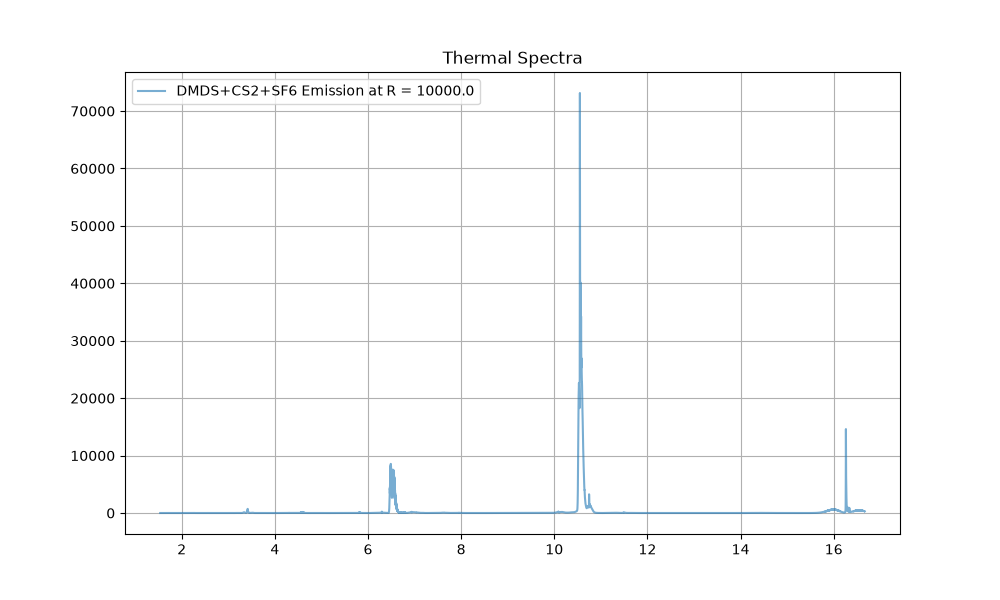

In [26]:
resolution_to_plot = 1e4
scenario_to_plot = 'DMDS+CS2+SF6'
snr_to_plot_a = 10
snr_to_plot_b = 50

R_bin = 1e3

data = res_dict[scenario_to_plot][resolution_to_plot]
x = data['wavelength_grid']
y = data['xsec_clean'] / np.median(data['xsec_clean'])


B = planck_wavelength(x,T=280) 

plt.figure(figsize=(10,6))

plt.plot(x,y, label = f'{scenario_to_plot} Emission at R = {resolution_to_plot}', alpha = 0.6)
plt.title('Thermal Spectra')
plt.grid()
plt.legend()
plt.show()